# 📊 Trend-Following Bot — Trade Statistics

This notebook loads and analyzes `trade_log.jsonl` produced by the Trend-Following Bot, providing statistical insights into trading performance, risk metrics, and strategy effectiveness.

## 1. Import Libraries and Load Trade Log

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import warnings
from pathlib import Path
from scipy import stats as sp_stats

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.size": 11,
})

# ── Load trade_log.jsonl ──────────────────────────────────────────────────────
LOG_PATH = Path(r"trade_log.jsonl")

records = []
with open(LOG_PATH, "r") as f:
    for line in f:
        line = line.strip()
        if line:
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                pass

df = pd.DataFrame(records)
print(f"Loaded {df.shape[0]} records  ×  {df.shape[1]} columns")

# ── Datetime conversion ───────────────────────────────────────────────────────
df["ts"] = pd.to_datetime(df["ts"], errors="coerce")

# ── Split by event type ───────────────────────────────────────────────────────
event_counts = df["event"].value_counts()

df_start       = df[df["event"] == "START"].copy()
df_stop        = df[df["event"] == "STOP"].copy()
df_enter       = df[df["event"] == "ENTER"].copy()
df_exit        = df[df["event"] == "EXIT"].copy()
df_force_close = df[df["event"] == "FORCE_CLOSE"].copy()
df_order_fail  = df[df["event"] == "ORDER_FAILED"].copy()

# ── Cast numeric columns where they exist ─────────────────────────────────────
_numeric_cols = [
    "pnl", "entry_price", "exit_price", "hold_time",
    "r2", "slope", "spread_at_entry", "slippage",
    "btc_price", "size_usdc", "spread",
    "mkt_elapsed_entry", "mkt_remaining_entry", "mkt_remaining_exit",
    "up_mid", "down_mid",
]

for col in _numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    for sub in [df_enter, df_exit, df_force_close]:
        if col in sub.columns:
            sub[col] = pd.to_numeric(sub[col], errors="coerce")

Loaded 515 records  ×  32 columns


## 2. General Performance Overview

Total Closed Trades,Wins,Losses,Win Rate (%),Total PnL (USDC),Avg Win,Avg Loss,Gross Wins,Gross Losses,Profit Factor
251,126,125,50.2%,+3637.8116,+61.2132,-32.6004,+7712.8656,-4075.0540,1.893


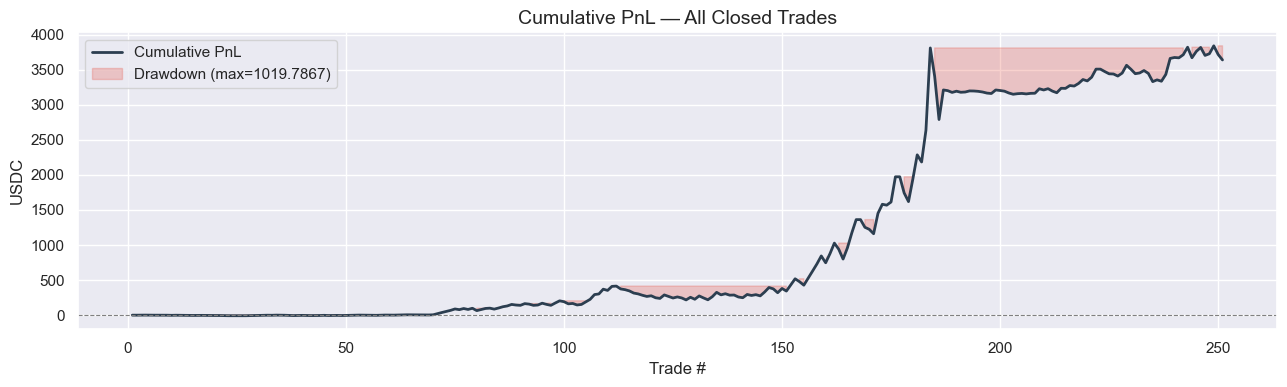

Max Drawdown: 1019.7867 USDC
Side Performance Summary:


,trades,wins,losses_count,total_pnl,avg_pnl,avg_win,avg_loss,gross_loss,win_rate_%
side,,,,,,,,,
down,117,59,58,3553.3180,30.3702,91.5744,-31.8891,-1849.569,50.4
up,134,67,67,84.4936,0.6305,34.4773,-33.2162,-2225.485,50.0


In [59]:
df_closed = pd.concat([df_exit, df_force_close], ignore_index=True)
df_closed["pnl"] = pd.to_numeric(df_closed["pnl"], errors="coerce")
df_closed["hold_time"] = pd.to_numeric(df_closed["hold_time"], errors="coerce")

total_trades = len(df_closed)
total_pnl    = df_closed["pnl"].sum()
avg_pnl      = df_closed["pnl"].mean() if total_trades else 0.0
wins         = (df_closed["pnl"] >= 0).sum()
losses       = (df_closed["pnl"] <  0).sum()
win_rate     = 100.0 * wins / total_trades if total_trades else 0.0
avg_win      = df_closed.loc[df_closed["pnl"] >= 0, "pnl"].mean() if wins else 0.0
avg_loss     = df_closed.loc[df_closed["pnl"] <  0, "pnl"].mean() if losses else 0.0
gross_wins   = df_closed.loc[df_closed["pnl"] > 0, "pnl"].sum()
gross_losses = df_closed.loc[df_closed["pnl"] < 0, "pnl"].sum()
profit_factor = abs(gross_wins / gross_losses) if gross_losses != 0 else np.inf
expectancy   = (win_rate / 100 * avg_win) + ((100 - win_rate) / 100 * avg_loss)

summary = pd.DataFrame([{
    "Total Closed Trades": total_trades,
    "Wins": wins,
    "Losses": losses,
    "Win Rate (%)": f"{win_rate:.1f}%",
    "Total PnL (USDC)": f"{total_pnl:+.4f}",
    "Avg Win": f"{avg_win:+.4f}",
    "Avg Loss": f"{avg_loss:+.4f}",
    "Gross Wins": f"{gross_wins:+.4f}",
    "Gross Losses": f"{gross_losses:+.4f}",
    "Profit Factor": f"{profit_factor:.3f}",
}])

display(summary.style.hide(axis="index"))

# ── Cumulative PnL + drawdown ────────────────────────────────────────────────
df_closed_sorted = df_closed.sort_values("ts").reset_index(drop=True)
df_closed_sorted["cum_pnl"] = df_closed_sorted["pnl"].cumsum()
running_max = df_closed_sorted["cum_pnl"].cummax()
drawdown    = running_max - df_closed_sorted["cum_pnl"]
max_dd      = drawdown.max()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df_closed_sorted.index + 1, df_closed_sorted["cum_pnl"], linewidth=2, color="#2c3e50", label="Cumulative PnL")
ax.fill_between(df_closed_sorted.index + 1, df_closed_sorted["cum_pnl"], running_max,
                where=drawdown > 0, alpha=0.25, color="#e74c3c", label=f"Drawdown (max={max_dd:.4f})")
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Cumulative PnL — All Closed Trades")
ax.set_xlabel("Trade #")
ax.set_ylabel("USDC")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Max Drawdown: {max_dd:.4f} USDC")

if "side" in df_closed.columns and df_closed["side"].notna().any():
    df_side = df_closed.copy()
    df_side["outcome"] = np.where(df_side["pnl"] >= 0, "WIN", "LOSS")

    side_stats = df_side.groupby("side").agg(
        trades=("pnl", "size"),
        wins=("outcome", lambda x: (x == "WIN").sum()),
        losses_count=("outcome", lambda x: (x == "LOSS").sum()),
        total_pnl=("pnl", "sum"),
        avg_pnl=("pnl", "mean"),
        avg_win=("pnl", lambda x: x[x >= 0].mean()),
        avg_loss=("pnl", lambda x: x[x < 0].mean()),
        gross_loss=("pnl", lambda x: x[x < 0].sum()),
    ).round(4)
    side_stats["win_rate_%"] = (side_stats["wins"] / side_stats["trades"] * 100).round(1)
    print("Side Performance Summary:")
    display(side_stats)

## 3. Loss Outlier Analysis — Which Trades Did the Most Damage?

In [60]:
df_losses = df_closed[df_closed["pnl"] < 0].copy()
df_losses_sorted = df_losses.sort_values("pnl").reset_index(drop=True)

# ── How concentrated are the losses? ─────────────────────────────────────────
total_loss_usdc = df_losses_sorted["pnl"].sum()
df_losses_sorted["cum_loss"] = df_losses_sorted["pnl"].cumsum()
df_losses_sorted["pct_of_total_loss"] = (df_losses_sorted["cum_loss"] / total_loss_usdc * 100).round(1)

print(f"Total losses: {losses}")
# ── 80/20 summary ─────────────────────────────────────────────────────────────
threshold_80 = (df_losses_sorted["pct_of_total_loss"] <= 80).sum()
print(f"\nTop {threshold_80} losses account for ≥80% of total gross loss ({total_loss_usdc:+.4f} USDC).")

print()
# ── Format remaining entry time as MM:SS (e.g. 300 -> 05:00) ─────────────────
if "mkt_remaining_entry" in df_losses_sorted.columns:
    df_losses_sorted["mkt_remaining_entry"] = pd.to_numeric(
        df_losses_sorted["mkt_remaining_entry"], errors="coerce"
    )
    df_losses_sorted["mkt_remaining_entry"] = df_losses_sorted["mkt_remaining_entry"].apply(
        lambda x: f"{int(x) // 60:02d}:{int(x) % 60:02d}" if pd.notna(x) else np.nan
    )
mrk_remaining_entry = "mkt_remaining_entry"   
# Show worst trades
worst_cols = [c for c in ["ts","side","entry_price","exit_price","pnl","exit_type",
                           "hold_time","r2","mkt_remaining_entry"]
              if c in df_losses_sorted.columns]
print("── Worst Trades (sorted by PnL) ──")
display(df_losses_sorted[worst_cols].head(15))


Total losses: 125

Top 33 losses account for ≥80% of total gross loss (-4075.0540 USDC).

── Worst Trades (sorted by PnL) ──


,ts,side,entry_price,exit_price,pnl,exit_type,hold_time,r2,mkt_remaining_entry
0,2026-04-16 23:43:57.110,down,0.64,0.525,-615.3268,stop_loss,5.1,0.7418,01:08
1,2026-04-16 22:50:31.862,up,0.71,0.635,-404.4599,stop_loss,10.5,0.9721,04:38
2,2026-04-16 20:40:44.672,down,0.52,0.460,-229.9635,stop_loss,18.6,0.7229,04:33
3,2026-04-17 18:06:08.957,up,0.64,0.510,-149.9623,stop_loss,28.9,0.6083,04:19
4,2026-04-16 16:15:30.304,up,0.72,0.615,-140.1111,stop_loss,5.0,0.6109,04:34
5,2026-04-16 21:20:40.859,up,0.50,0.465,-123.4138,stop_loss,11.1,0.6181,04:30
6,2026-04-17 19:54:07.046,up,0.71,0.595,-122.7907,stop_loss,6.0,0.7617,00:58
7,2026-04-17 16:04:11.409,up,0.64,0.435,-116.8570,stop_loss,6.1,0.6200,00:54
8,2026-04-17 18:59:42.084,up,0.68,0.575,-113.4922,stop_loss,6.6,0.9177,00:24
9,2026-04-16 17:05:39.278,down,0.57,0.525,-109.1590,stop_loss,6.5,0.6546,04:27


## 5. Entry Conditions on Losses vs Wins

This section compares entry-time signals (e.g., `r2`, `slope`, `spread_at_entry`, `slippage`) between winning and losing trades to highlight filters that may improve trade quality.

In [61]:
feature_cols = ["r2", "slope", "spread_at_entry", "slippage"]
df_features = df_closed.dropna(subset=["pnl"]).copy()
df_features["outcome"] = np.where(df_features["pnl"] >= 0, "WIN", "LOSS")

for col in feature_cols:
    if col in df_features.columns:
        df_features[col] = pd.to_numeric(df_features[col], errors="coerce")

available_features = [
    c for c in feature_cols
    if c in df_features.columns and df_features[c].notna().sum() > 3
]

if not available_features:
    print("No entry-condition feature columns available for comparison.")
else:
    rows = []
    for col in available_features:
        sub = df_features.dropna(subset=[col])
        win_vals = sub.loc[sub["outcome"] == "WIN", col]
        loss_vals = sub.loc[sub["outcome"] == "LOSS", col]

        p_val = np.nan
        if len(win_vals) > 1 and len(loss_vals) > 1:
            _, p_val = sp_stats.mannwhitneyu(win_vals, loss_vals, alternative="two-sided")

        rows.append({
            "feature": col,
            "win_mean": win_vals.mean(),
            "loss_mean": loss_vals.mean(),
            "delta_win_minus_loss": win_vals.mean() - loss_vals.mean(),
            "p_value": p_val,
            "win_n": len(win_vals),
            "loss_n": len(loss_vals),
        })

    feature_summary = pd.DataFrame(rows).sort_values("p_value", na_position="last")
    display(feature_summary.round(5))


,feature,win_mean,loss_mean,delta_win_minus_loss,p_value,win_n,loss_n
1,slope,0.02552,0.02673,-0.00121,0.21506,126,125
0,r2,0.77054,0.75247,0.01807,0.43038,126,125
2,spread_at_entry,0.01484,0.01440,0.00044,0.63955,126,125
3,slippage,0.00742,0.00720,0.00022,0.63955,126,125


## 6. Market Timing on Losses

Does entering too early or too late in a market window predict losses? Compare elapsed/remaining time at entry for wins vs losses.

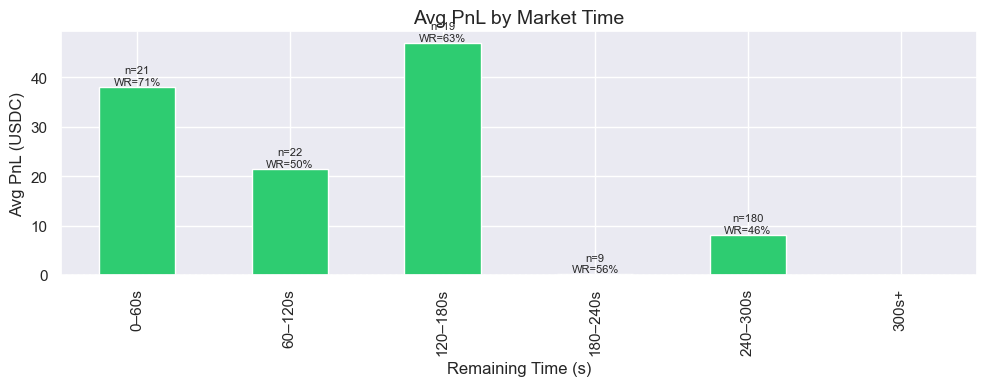

In [62]:
timing_cols = ["mkt_elapsed_entry", "mkt_remaining_entry"]
df_timing = df_closed.dropna(subset=["pnl"]).copy()
for c in timing_cols:
    if c in df_timing.columns:
        df_timing[c] = pd.to_numeric(df_timing[c], errors="coerce")
df_timing["outcome"] = np.where(df_timing["pnl"] >= 0, "WIN", "LOSS")
palette = {"WIN": "#2ecc71", "LOSS": "#e74c3c"}

avail_timing = [c for c in timing_cols if c in df_timing.columns and df_timing[c].notna().any()]

# ── Avg PnL bucketed by remaining time ───────────────────────────────────
if "mkt_remaining_entry" in df_timing.columns and df_timing["mkt_remaining_entry"].notna().any():
    df_timing["remain_bucket"] = pd.cut(
        df_timing["mkt_remaining_entry"],
        bins=[0, 60, 120, 180, 240, 300, 600],
        labels=["0–60s", "60–120s", "120–180s", "180–240s", "240–300s", "300s+"],
        include_lowest=True,
    )
    bucket_stats = (
        df_timing.groupby("remain_bucket", observed=False)["pnl"]
        .agg(trades="count", avg_pnl="mean", win_rate=lambda x: (x >= 0).mean() * 100)
        .round(4)
    )
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in bucket_stats["avg_pnl"]]
    bucket_stats["avg_pnl"].plot.bar(ax=ax2, color=colors, edgecolor="white")
    ax2.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax2.set_title("Avg PnL by Market Time")
    ax2.set_xlabel("Remaining Time (s)")
    ax2.set_ylabel("Avg PnL (USDC)")
    for idx, row in enumerate(bucket_stats.itertuples()):
        ax2.text(idx, row.avg_pnl, f"n={int(row.trades)}\nWR={row.win_rate:.0f}%",
                 ha="center", va="bottom" if row.avg_pnl >= 0 else "top", fontsize=8)
    plt.tight_layout()
    plt.show()


## 7. Statistical Significance Check (Timing Features)

In [63]:
print("Mann-Whitney U test (WIN vs LOSS) for timing columns:")
if not avail_timing:
    print("No timing columns available for statistical testing.")
else:
    for col in avail_timing:
        sub = df_timing.dropna(subset=[col])
        win_vals = sub[sub["outcome"] == "WIN"][col].values
        loss_vals = sub[sub["outcome"] == "LOSS"][col].values
        if len(win_vals) > 1 and len(loss_vals) > 1:
            _, p = sp_stats.mannwhitneyu(win_vals, loss_vals, alternative="two-sided")
            sig = "significant" if p < 0.05 else "not significant"
            print(f"  {col:30s}: p = {p:.4f} ({sig})")
        else:
            print(f"  {col:30s}: insufficient samples")

print("\n Mann-Whitney U test (WIN vs LOSS) for entry-condition features:")
if not available_features:
    print("No entry-condition feature columns available for statistical testing.")
else:
    for col in available_features:
        sub = df_features.dropna(subset=[col])
        win_vals = sub[sub["outcome"] == "WIN"][col].values
        loss_vals = sub[sub["outcome"] == "LOSS"][col].values
        if len(win_vals) > 1 and len(loss_vals) > 1:
            _, p = sp_stats.mannwhitneyu(win_vals, loss_vals, alternative="two-sided")
            sig = "significant" if p < 0.05 else "not significant"
            print(f"  {col:30s}: p = {p:.4f} ({sig})")
        else:
            print(f"  {col:30s}: insufficient samples")


Mann-Whitney U test (WIN vs LOSS) for timing columns:
  mkt_elapsed_entry             : p = 0.0452 (significant)
  mkt_remaining_entry           : p = 0.0452 (significant)

 Mann-Whitney U test (WIN vs LOSS) for entry-condition features:
  r2                            : p = 0.4304 (not significant)
  slope                         : p = 0.2151 (not significant)
  spread_at_entry               : p = 0.6396 (not significant)
  slippage                      : p = 0.6396 (not significant)


## 8. Consecutive Loss Streaks & Drawdown Periods

Loss streaks compound drawdowns faster than individual losses. This section finds streak patterns and flags when the bot was most at risk.

In [64]:
df_streak_input = df_closed.sort_values("ts").dropna(subset=["pnl"]).copy()
df_streak_input["is_loss"] = df_streak_input["pnl"] < 0

streaks = []
current_len = 0
start_ts = None
end_ts = None
for row in df_streak_input.itertuples():
    if row.is_loss:
        current_len += 1
        if current_len == 1:
            start_ts = row.ts
        end_ts = row.ts
    elif current_len > 0:
        streaks.append({"start_ts": start_ts, "end_ts": end_ts, "length": current_len})
        current_len = 0
        start_ts = None
        end_ts = None

if current_len > 0:
    streaks.append({"start_ts": start_ts, "end_ts": end_ts, "length": current_len})

df_streaks = pd.DataFrame(streaks)
max_streak = int(df_streaks["length"].max()) if not df_streaks.empty else 0
print(f"Max consecutive losing streak: {max_streak} trades")
print(f"Total losing streaks found: {len(df_streaks)}")

if df_streaks.empty:
    print("No loss streaks found.")
else:
    display(df_streaks.sort_values("length", ascending=False).head(10))

Max consecutive losing streak: 10 trades
Total losing streaks found: 62


,start_ts,end_ts,length
4,2026-04-14 07:20:37.083,2026-04-14 10:00:33.897,10
23,2026-04-16 06:05:40.782,2026-04-16 06:34:04.725,7
46,2026-04-17 08:35:36.621,2026-04-17 09:10:36.013,5
12,2026-04-15 17:45:51.851,2026-04-15 19:45:38.381,4
3,2026-04-14 04:25:43.018,2026-04-14 06:15:47.992,4
6,2026-04-14 12:45:59.180,2026-04-14 13:58:20.443,4
47,2026-04-17 09:45:48.581,2026-04-17 10:05:45.004,4
54,2026-04-17 12:20:57.008,2026-04-17 13:00:39.809,4
10,2026-04-14 19:20:57.149,2026-04-15 04:03:09.857,3
2,2026-04-14 03:20:38.063,2026-04-14 03:40:37.206,3


## 8. Exit Type Breakdown

This section categorizes trades by exit type (take profit, stop loss, time-based exit) and analyzes the performance of each exit strategy to identify which is most effective.

,count,avg_pnl,total_pnl,avg_hold_time
exit_group,,,,
stop_loss,173,-15.7195,-2719.4669,15.6699
take_profit,76,81.2959,6178.4854,14.8553
other,2,89.3966,178.7931,19.9500


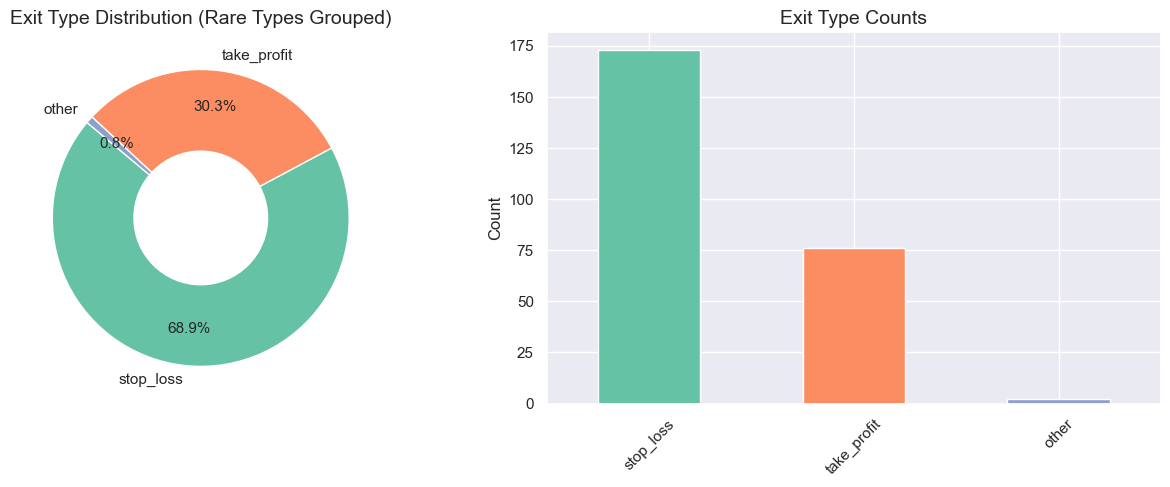

In [65]:
if "exit_type" in df_closed.columns:
    exit_type_clean = (
        df_closed["exit_type"]
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    exit_type_counts = exit_type_clean.value_counts()
    rare_mask = exit_type_clean.map(exit_type_counts) < 3
    exit_type_grouped = exit_type_clean.where(~rare_mask, other="other")
    grouped_counts = exit_type_grouped.value_counts()

    exit_type_stats = (
        df_closed.assign(exit_group=exit_type_grouped)
        .groupby("exit_group")
        .agg(
            count=("pnl", "size"),
            avg_pnl=("pnl", "mean"),
            total_pnl=("pnl", "sum"),
            avg_hold_time=("hold_time", "mean"),
        )
        .round(4)
        .sort_values("count", ascending=False)
    )
    display(exit_type_stats)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    colors = sns.color_palette("Set2", n_colors=len(grouped_counts))

    wedges, texts, autotexts = axes[0].pie(
        grouped_counts.values,
        labels=grouped_counts.index,
        autopct="%1.1f%%",
        colors=colors,
        startangle=140,
        wedgeprops={"edgecolor": "white"},
        pctdistance=0.75,
    )
    centre_circle = plt.Circle((0, 0), 0.45, fc="white")
    axes[0].add_artist(centre_circle)
    axes[0].set_title("Exit Type Distribution (Rare Types Grouped)")

    grouped_counts.plot.bar(ax=axes[1], color=colors, edgecolor="white")
    axes[1].set_title("Exit Type Counts")
    axes[1].set_ylabel("Count")
    axes[1].set_xlabel("")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()
else:
    print("No 'exit_type' column found in closed trades.")

## 9. Decision Report (Narrative + Charts)

This final section generates a decision-ready narrative report and includes key visuals for quick review.


## Trading Review Report

### 1. Scope
- Window: last 7 days
- Sample size: 251 closed trades
- Mode scope: Mixed/unspecified (paper and live not separated in this notebook)

### 2. Headline Metrics
- Win rate: 50.2% (126W / 125L)
- Total PnL: +3637.8116 USDC
- Avg PnL per trade: +14.4933 USDC
- Median PnL: +0.0000 USDC
- P10 / P90 PnL: -34.4579 / +87.3009 USDC
- Largest gain / loss: +1172.1083 / -615.3268 USDC

### 3. Risk Findings
- Max drawdown in scope: 1019.7867 USDC
- Max consecutive loss streak: 10
- Worst 13 losses contribute 59.2% of gross losses.
- FORCE_CLOSE share: 0.0% (not dominated by FORCE_CLOSE events).

### 4. Drift vs Baseline
- Insufficient baseline sample for strict drift comparison (need >=20 recent and >=20 baseline closes).

### 5. Actions: Keep / Adjust / Investigate
- Keep: Keep current core setup while monitoring drawdown and streak behavior.
- Adjust: Adjust one filter at a time (for example timing gate or spread/slippage limit) and re-check drift next cycle.
- Investigate: Investigate top loss cluster windows and FORCE_CLOSE-heavy periods for execution or market-rotation issues.

### 6. Recommended Cadence
- Next review cadence: every 3 days
- Rationale: Mixed signals without severe deterioration.

### 7. Confidence and Data Quality Notes
- Confidence: High
- Note: Sufficient sample size for directional decisions.
- Data quality: malformed-row rate is not tracked in the loader.


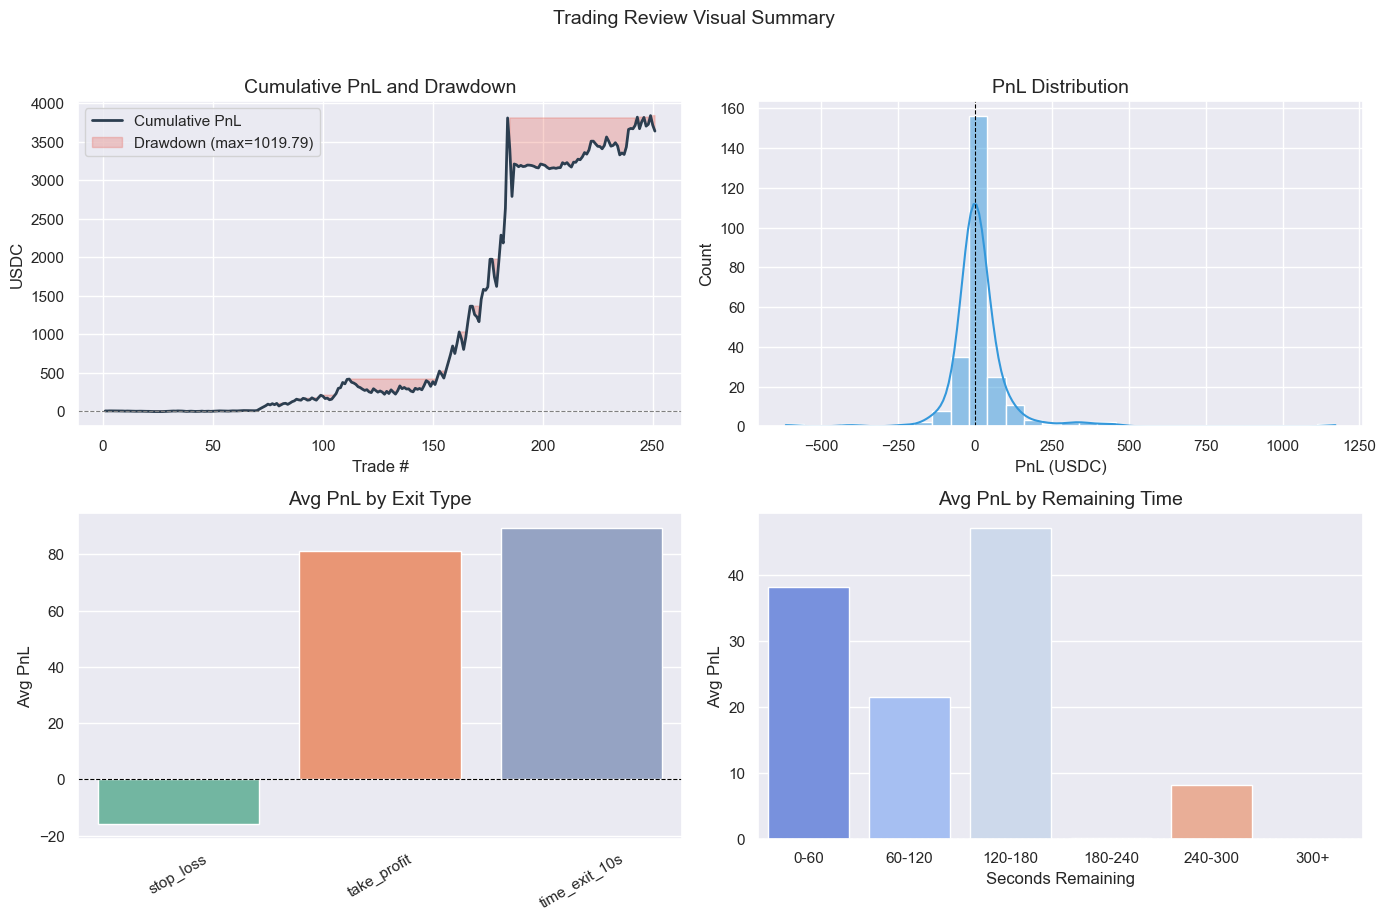

Saved report markdown: reports\trading_review_20260417_203754.md
Saved report image:    reports\trading_review_20260417_203754.png
Updated latest files:  reports\trading_review_latest.md and reports\trading_review_latest.png


In [ ]:
from IPython.display import Markdown, display
from pathlib import Path
from datetime import datetime

closed = df_closed.copy()
closed = closed.dropna(subset=["ts", "pnl"]).sort_values("ts")

if closed.empty:
    display(Markdown("No closed trades found. Run earlier cells and verify the log contains EXIT/FORCE_CLOSE events."))
else:
    # Scope
    window_days = 7
    baseline_days = 30
    end_ts = closed["ts"].max()
    recent_start = end_ts - pd.Timedelta(days=window_days)
    baseline_start = end_ts - pd.Timedelta(days=baseline_days)

    recent = closed[closed["ts"] >= recent_start].copy()
    baseline = closed[(closed["ts"] >= baseline_start) & (closed["ts"] < recent_start)].copy()

    use_recent = len(recent) > 0
    report_df = recent if use_recent else closed
    report_label = f"last {window_days} days" if use_recent else "all available history"

    # Headline metrics
    n = len(report_df)
    wins_n = int((report_df["pnl"] >= 0).sum())
    losses_n = int((report_df["pnl"] < 0).sum())
    win_rate_pct = (wins_n / n * 100) if n else 0.0
    total_pnl_usdc = float(report_df["pnl"].sum())
    avg_pnl_usdc = float(report_df["pnl"].mean()) if n else 0.0
    median_pnl_usdc = float(report_df["pnl"].median()) if n else 0.0
    p90_pnl_usdc = float(report_df["pnl"].quantile(0.90)) if n else 0.0
    p10_pnl_usdc = float(report_df["pnl"].quantile(0.10)) if n else 0.0
    largest_gain = float(report_df["pnl"].max()) if n else 0.0
    largest_loss = float(report_df["pnl"].min()) if n else 0.0

    # Risk checks
    rep_sorted = report_df.sort_values("ts").copy()
    rep_sorted["cum_pnl"] = rep_sorted["pnl"].cumsum()
    rep_running_max = rep_sorted["cum_pnl"].cummax()
    report_drawdown = rep_running_max - rep_sorted["cum_pnl"]
    report_max_dd = float(report_drawdown.max()) if len(report_drawdown) else 0.0

    # Consecutive losses
    is_loss = (rep_sorted["pnl"] < 0).astype(int).tolist()
    max_loss_streak = 0
    cur = 0
    for flag in is_loss:
        if flag:
            cur += 1
            if cur > max_loss_streak:
                max_loss_streak = cur
        else:
            cur = 0

    # Outlier concentration (loss side)
    losses_only = report_df[report_df["pnl"] < 0]["pnl"].sort_values()
    outlier_note = "No losses in selected window."
    if len(losses_only) > 0:
        gross_loss_abs = float(abs(losses_only.sum()))
        k = max(1, int(np.ceil(0.10 * len(losses_only))))
        top_k_abs = float(abs(losses_only.head(k).sum()))
        concentration_pct = (top_k_abs / gross_loss_abs * 100) if gross_loss_abs > 0 else 0.0
        outlier_note = f"Worst {k} losses contribute {concentration_pct:.1f}% of gross losses."

    # FORCE_CLOSE dominance
    force_close_share = np.nan
    dominated_by_force_close = False
    if "event" in report_df.columns:
        force_close_n = int((report_df["event"] == "FORCE_CLOSE").sum())
        force_close_share = (force_close_n / n * 100) if n else np.nan
        dominated_by_force_close = force_close_share >= 50

    # Drift vs baseline
    drift_lines = []
    high_risk = False
    stable = False

    recent_win_rate = (recent["pnl"] >= 0).mean() * 100 if len(recent) else np.nan
    base_win_rate = (baseline["pnl"] >= 0).mean() * 100 if len(baseline) else np.nan
    recent_avg = float(recent["pnl"].mean()) if len(recent) else np.nan
    base_avg = float(baseline["pnl"].mean()) if len(baseline) else np.nan

    if len(recent) >= 20 and len(baseline) >= 20:
        wr_delta = recent_win_rate - base_win_rate
        avg_delta = recent_avg - base_avg
        drift_lines.append(f"Recent win rate: {recent_win_rate:.1f}% vs baseline {base_win_rate:.1f}% (delta {wr_delta:+.1f} pts).")
        drift_lines.append(f"Recent avg PnL: {recent_avg:+.4f} vs baseline {base_avg:+.4f} (delta {avg_delta:+.4f}).")

        if wr_delta <= -5:
            high_risk = True
        if report_max_dd > max(1.15 * abs(base_avg) * len(recent), 1e-9):
            high_risk = True
        if (wr_delta >= 0) and (avg_delta >= 0):
            stable = True
    else:
        drift_lines.append("Insufficient baseline sample for strict drift comparison (need >=20 recent and >=20 baseline closes).")

    # Cadence policy
    if high_risk:
        cadence = "every 1 day"
        cadence_reason = "Win-rate deterioration and/or elevated risk signal."
    elif stable:
        cadence = "every 7 days"
        cadence_reason = "Metrics are stable/improving against baseline."
    else:
        cadence = "every 3 days"
        cadence_reason = "Mixed signals without severe deterioration."

    # Confidence
    if n < 20:
        confidence = "Low"
        conf_note = "Sample has fewer than 20 closes in scope."
    elif n < 60:
        confidence = "Medium"
        conf_note = "Moderate sample size."
    else:
        confidence = "High"
        conf_note = "Sufficient sample size for directional decisions."

    # Actions
    keep_line = "Keep current core setup while monitoring drawdown and streak behavior."
    adjust_line = "Adjust one filter at a time (for example timing gate or spread/slippage limit) and re-check drift next cycle."
    investigate_line = "Investigate top loss cluster windows and FORCE_CLOSE-heavy periods for execution or market-rotation issues."

    force_close_line = (
        f"FORCE_CLOSE share: {force_close_share:.1f}% ({'dominated' if dominated_by_force_close else 'not dominated'} by FORCE_CLOSE events)."
        if pd.notna(force_close_share)
        else "FORCE_CLOSE share unavailable (event column missing)."
    )

    report_md = f"""
## Trading Review Report

### 1. Scope
- Window: {report_label}
- Sample size: {n} closed trades
- Mode scope: Mixed/unspecified (paper and live not separated in this notebook)

### 2. Headline Metrics
- Win rate: {win_rate_pct:.1f}% ({wins_n}W / {losses_n}L)
- Total PnL: {total_pnl_usdc:+.4f} USDC
- Avg PnL per trade: {avg_pnl_usdc:+.4f} USDC
- Median PnL: {median_pnl_usdc:+.4f} USDC
- P10 / P90 PnL: {p10_pnl_usdc:+.4f} / {p90_pnl_usdc:+.4f} USDC
- Largest gain / loss: {largest_gain:+.4f} / {largest_loss:+.4f} USDC

### 3. Risk Findings
- Max drawdown in scope: {report_max_dd:.4f} USDC
- Max consecutive loss streak: {max_loss_streak}
- {outlier_note}
- {force_close_line}

### 4. Drift vs Baseline
- {' '.join(drift_lines)}

### 5. Actions: Keep / Adjust / Investigate
- Keep: {keep_line}
- Adjust: {adjust_line}
- Investigate: {investigate_line}

### 6. Recommended Cadence
- Next review cadence: {cadence}
- Rationale: {cadence_reason}

### 7. Confidence and Data Quality Notes
- Confidence: {confidence}
- Note: {conf_note}
- Data quality: malformed-row rate is not tracked in the loader.
    """

    display(Markdown(report_md))    
